## Vertiport and Spatial Data Initialization

In [ ]:
import pandas as pd
import geopandas as gpd
import folium
import requests
import itertools
from shapely.geometry import Polygon


# -----------------------------
# A) Vertiports (your points)
# -----------------------------
verts = pd.DataFrame({
    "name": [
        "Dallas CBD",
        "DFW Airport",
        "Dallas Love Field Airport",
        "Fort Worth City Center",
        "Mesquite Metro Airport",
        "Dallas Executive Airport (RBD)",
        "Denton Municipal Airport",
        "Fort Worth Meacham International Airport",
        "Arlington Municipal Airport",
        "McKinney National Airport"
    ],
    "lat": [
        32.7767, 32.8998, 32.84815, 32.75550, 32.7470,
        32.6810, 33.20083, 32.81969, 32.6639, 33.1753
    ],
    "lon": [
        -96.7970, -97.0409, -96.85135, -97.33080, -96.5304,
        -96.8690, -97.19778, -97.36319, -97.0943, -96.5825
    ]
})

verts_gdf = gpd.GeoDataFrame(
    verts,
    geometry=gpd.points_from_xy(verts["lon"], verts["lat"]),
    crs="EPSG:4326"
)


tracts = gpd.read_file(r"tl_2022_48_tract\tl_2022_48_tract.shp").to_crs(epsg=4326)

## Population Integration and Vertiport Catchment Modeling

In [ ]:
from shapely.geometry import Polygon
# -------------------------
# 3) Pull ACS population (2022 ACS 5-year) by tract, Texas, USA
#     Variable: B01003_001E = Total population
# -------------------------
url = "https://api.census.gov/data/2022/acs/acs5"
params = {"get": "NAME,B01003_001E", "for": "tract:*", "in": "state:48"}
resp = requests.get(url, params=params)
resp.raise_for_status()
acs = resp.json()

columns = acs[0]
rows = acs[1:]
pop = pd.DataFrame(rows, columns=columns)
pop["GEOID"] = pop["state"] + pop["county"] + pop["tract"]
pop["population"] = pop["B01003_001E"].astype(int)
pop = pop[["GEOID", "population"]]

# Merge pop onto tracts
tracts_pop = tracts.merge(pop, on="GEOID", how="left").dropna(subset=["population"])

# -------------------------
# 4) Clip to bounding box around DFW region
# -------------------------
min_lon, min_lat = -97.60, 32.30
max_lon, max_lat = -96.20, 33.30

rect = Polygon([
    (min_lon, min_lat),
    (min_lon, max_lat),
    (max_lon, max_lat),
    (max_lon, min_lat)
])

tracts_in_rect = tracts_pop[tracts_pop.intersects(rect)].copy()


# -------------------------
# 5) Assign each tract centroid to nearest vertiport
# -------------------------
centroids = tracts_in_rect.copy()
centroids["centroid"] = centroids.geometry.centroid
centroids = centroids.set_geometry("centroid")

# Project for distance in meters
verts_proj = verts_gdf.to_crs(epsg=3857)
centroids_proj = centroids.to_crs(epsg=3857)

nearest_idx = centroids_proj.geometry.apply(lambda p: verts_proj.distance(p).idxmin())
centroids_proj["nearest_vertiport"] = nearest_idx.apply(lambda i: verts_gdf.loc[i, "name"])

# 30% UAM adoption
centroids_proj["uam_population"] = centroids_proj["population"] * 0.30

uam_pop_by_vertiport = (
    centroids_proj.groupby("nearest_vertiport")["uam_population"]
    .sum()
    .sort_values(ascending=False)
)


# -------------------------
# 6) Color tracts by nearest vertiport (map)
# -------------------------
colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"
]
vert_names = centroids_proj["nearest_vertiport"].unique()
color_cycle = itertools.cycle(colors)
color_map = {name: next(color_cycle) for name in vert_names}

tracts_map = tracts_in_rect.copy()
tracts_map["nearest_vertiport"] = centroids_proj["nearest_vertiport"].values
tracts_map = tracts_map.to_crs(epsg=4326)

m1 = folium.Map(location=[32.85, -97.0], zoom_start=10)

folium.Polygon(
    locations=[(min_lat, min_lon), (max_lat, min_lon), (max_lat, max_lon), (min_lat, max_lon)],
    color="red",
    weight=2,
    fill=False
).add_to(m1)

folium.GeoJson(
    tracts_map.to_json(),
    style_function=lambda feature: {
        "fillColor": color_map.get(feature["properties"]["nearest_vertiport"], "#cccccc"),
        "color": "black",
        "weight": 0.2,
        "fillOpacity": 0.55,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["GEOID", "nearest_vertiport", "population"],
        aliases=["Census Tract", "Nearest Vertiport", "Population"],
        localize=True
    )
).add_to(m1)

for _, r in verts_gdf.iterrows():
    folium.Marker(
        location=[r.geometry.y, r.geometry.x],
        tooltip=r["name"],
        icon=folium.Icon(color="blue", icon="plane", prefix="fa")
    ).add_to(m1)

display(m1)
print("UAM population by vertiport (30% of tract pop):")
display(uam_pop_by_vertiport.to_frame("uam_pop"))

<ipython-input-2-b05c214c4162>:42: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids["centroid"] = centroids.geometry.centroid


UAM population by vertiport (30% of tract pop):


,uam_pop
nearest_vertiport,
McKinney National Airport,320463.9
Dallas Love Field Airport,302782.5
DFW Airport,249990.0
Arlington Municipal Airport,245816.4
Mesquite Metro Airport,230367.0
Fort Worth City Center,228296.7
Dallas Executive Airport (RBD),184887.0
Fort Worth Meacham International Airport,182208.0
Dallas CBD,152455.8


## Gravity Demand Modeling and Flow Visualization

In [3]:
# -------------------------
# 7) Gravity model: flows from DFW to all other vertiports
# -------------------------
vp = verts_gdf.merge(
    uam_pop_by_vertiport.rename("uam_pop"),
    left_on="name",
    right_index=True,
    how="inner"
).copy()

vp_proj = vp.to_crs(epsg=3857)

dfw_name = "DFW Airport"
dfw_row = vp_proj[vp_proj["name"] == dfw_name].iloc[0]
dfw_idx = dfw_row.name
P_dfw = float(dfw_row["uam_pop"])

gamma = 1.1  # distance decay
flows = []

for idx, row in vp_proj.iterrows():
    if idx == dfw_idx:
        continue

    P_j = float(row["uam_pop"])
    dist_km = float(dfw_row.geometry.distance(row.geometry) / 1000.0)
    dist_km = max(dist_km, 1e-6)  # avoid divide-by-zero (shouldn't happen)

    raw = (P_dfw * P_j) / (dist_km ** gamma)

    flows.append({
        "origin": dfw_name,
        "destination": row["name"],
        "distance_km": dist_km,
        "uam_pop_dfw": P_dfw,
        "uam_pop_dest": P_j,
        "raw_gravity": raw
    })

flows_df = pd.DataFrame(flows)


# --------------------------------------------------
# Enforce: (1) Dallas CBD highest, (2) TOTAL trips = 1000
# --------------------------------------------------

CBD_BOOST = 2.0
TOTAL_TRIPS_TARGET = 1000.0

# 1) Apply CBD boost
flows_df["raw_gravity_adj"] = flows_df["raw_gravity"].copy()
flows_df.loc[flows_df["destination"] == "Dallas CBD", "raw_gravity_adj"] *= CBD_BOOST

# 2) Increase boost if CBD is not the highest
for _ in range(20):
    top_dest = flows_df.loc[
        flows_df["raw_gravity_adj"].idxmax(), "destination"
    ]
    if top_dest == "Dallas CBD":
        break

    CBD_BOOST *= 1.5
    flows_df["raw_gravity_adj"] = flows_df["raw_gravity"]
    flows_df.loc[
        flows_df["destination"] == "Dallas CBD", "raw_gravity_adj"
    ] *= CBD_BOOST

# 3) Scale so TOTAL trips = 1000
sum_raw = flows_df["raw_gravity_adj"].sum()
K = TOTAL_TRIPS_TARGET / sum_raw if sum_raw > 0 else 0.0

flows_df["DFW_to_dest_trips"] = flows_df["raw_gravity_adj"] * K
flows_df["DFW_to_dest_trips"] = flows_df["DFW_to_dest_trips"].round(2)

flows_df_sorted = flows_df.sort_values(
    "DFW_to_dest_trips", ascending=False
)

print(f"CBD_BOOST used: {CBD_BOOST:.2f}")
print(
    f"Total trips: "
    f"{flows_df_sorted['DFW_to_dest_trips'].sum():.2f}"
)
display(flows_df_sorted)

# -------------------------
# 8) Map: DFW → destination flow lines
# -------------------------
m2 = folium.Map(location=[32.85, -97.0], zoom_start=10)

for _, r in verts_gdf.iterrows():
    folium.Marker(
        location=[r.geometry.y, r.geometry.x],
        popup=r["name"],
        tooltip=r["name"],
        icon=folium.Icon(color="blue", icon="plane", prefix="fa")
    ).add_to(m2)

# Draw lines (skip very small flows for readability)
for _, row in flows_df_sorted.iterrows():
    trips = float(row["DFW_to_dest_trips"])
    if trips < 50:
        continue

    origin_geom = vp_proj[vp_proj["name"] == row["origin"]].geometry.iloc[0]
    dest_geom   = vp_proj[vp_proj["name"] == row["destination"]].geometry.iloc[0]

    origin_latlon = gpd.GeoSeries([origin_geom], crs=3857).to_crs(4326).iloc[0]
    dest_latlon   = gpd.GeoSeries([dest_geom],   crs=3857).to_crs(4326).iloc[0]

    folium.PolyLine(
        locations=[[origin_latlon.y, origin_latlon.x], [dest_latlon.y, dest_latlon.x]],
        color="black",
        weight=min(20, trips / 100.0),
        opacity=0.65,
        tooltip=f"{row['origin']} → {row['destination']}: {trips:.1f} trips/day"
    ).add_to(m2)

display(m2)

CBD_BOOST used: 3.00
Total trips: 1000.01


,origin,destination,distance_km,uam_pop_dfw,uam_pop_dest,raw_gravity,raw_gravity_adj,DFW_to_dest_trips
0,DFW Airport,Dallas CBD,31.672882,249990.0,152455.8,8.517463e+08,2.555239e+09,226.46
1,DFW Airport,Dallas Love Field Airport,22.183377,249990.0,302782.5,2.502782e+09,2.502782e+09,221.81
7,DFW Airport,Arlington Municipal Airport,31.795445,249990.0,245816.4,1.367515e+09,1.367515e+09,121.20
2,DFW Airport,Fort Worth City Center,37.508383,249990.0,228296.7,1.058964e+09,1.058964e+09,93.85
4,DFW Airport,Dallas Executive Airport (RBD),34.722321,249990.0,184887.0,9.335969e+08,9.335969e+08,82.74
6,DFW Airport,Fort Worth Meacham International Airport,37.414955,249990.0,182208.0,8.475012e+08,8.475012e+08,75.11
8,DFW Airport,McKinney National Airport,62.787803,249990.0,320463.9,8.434104e+08,8.434104e+08,74.75
3,DFW Airport,Mesquite Metro Airport,60.325761,249990.0,230367.0,6.335630e+08,6.335630e+08,56.15
5,DFW Airport,Denton Municipal Airport,43.627429,249990.0,137696.7,5.408920e+08,5.408920e+08,47.94


## EVTOL & Passenger arrival time distribution

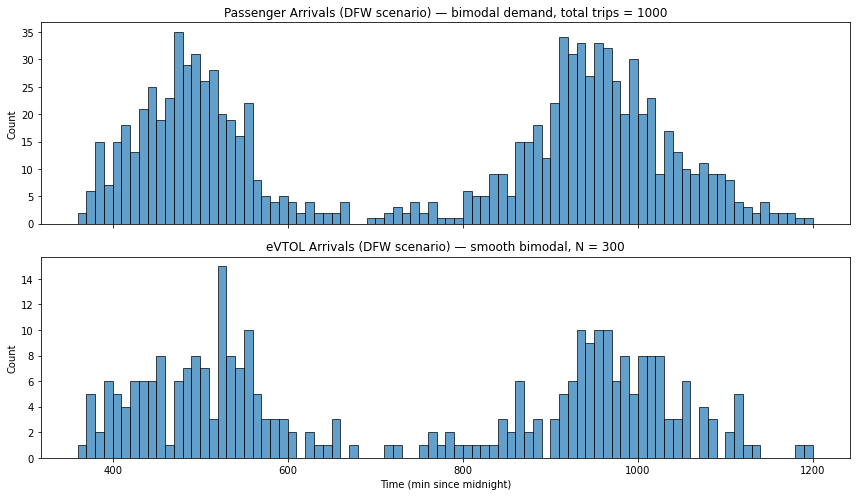

Destination assignment check (sampled vs target):


,trips_target (from demand model),trips_sampled (this scenario),share_sampled
Dallas CBD,226.46,192,0.192
Dallas Love Field Airport,221.81,212,0.212
Arlington Municipal Airport,121.20,138,0.138
Fort Worth City Center,93.85,107,0.107
Dallas Executive Airport (RBD),82.74,93,0.093
Fort Worth Meacham International Airport,75.11,78,0.078
McKinney National Airport,74.75,80,0.080
Mesquite Metro Airport,56.15,55,0.055
Denton Municipal Airport,47.94,45,0.045


In [4]:
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
import folium
import math

# eVTOL Stochastic Scheduling - Global Configuration

# Simulation Settings
BASE_PRICE = 0.1482   # Average residential electricity rate in Dallas (PowerChoiceTexas.org, 2025)
M_PEAK = 1.5          # CoServ TOU Rate Sheet: Peak ≈ 20.92¢/kWh
M_SHOULDER = 1.05     # Shoulder multiplier (transitional pricing)
M_OFF = 0.6           # CoServ TOU Rate Sheet: Off-peak ≈ 8.56¢/kWh
# Reference: https://www.powerchoicetexas.org/cities/dallas-electricity-rates , https://www.coserv.com/service/residential/residential-rates/

# eVTOL and Battery Parameters
SOC_MIN = 70.0                      # Minimum required state of charge (%)
BATTERY_CAPACITY = 150.0            # Battery capacity in kWh
CHARGING_RATE = 125                 # Charging power in kW
EVTOL_CAPACITY = 4                  # Maximum passengers per eVTOL
# Reference: Z. Wu, Y. Zhang, Optimal eVTOL charging and passenger scheduling, AIAA Aviation 2020 Forum, 2020.

# Scenario Generation Parameters
N_SCENARIOS = 30                    # Number of demand scenarios generated
TARGET_SCENARIOS = 3                # Number of reduced representative scenarios
HORIZON_START = 360   # 6AM
HORIZON_END = 1200   # 8 PM
HORIZON_MINUTES = HORIZON_END - HORIZON_START              # 14-hour simulation horizon (840 minutes)
BIN_SIZE = 10                       # Each time bin equals 10 minutes
L_PERIODS = HORIZON_MINUTES // BIN_SIZE   # 84 periods (14h × 60 / 10)

# Model Parameters
M_FACILITIES = 3                    # Number of charging facilities
LOS = 2                             # Level of Service: maximum waiting time (2 periods = 20 min)

# Randomization Control
SEED = 60                           # Random seed for reproducibility

TOTAL_PASSENGER_TRIPS = int(round(flows_df_sorted["DFW_to_dest_trips"].sum()))
N_EVTOL = 300
HUB_NAME = "DFW Airport"
# -----------------------------
# VERTIPORT NETWORK
# -----------------------------
vertiports = {
    "Dallas CBD": (32.7767, -96.7970),
    "DFW Airport": (32.8998, -97.0409),
    "Dallas Love Field Airport": (32.84815, -96.85135),
    "Fort Worth City Center": (32.75550, -97.33080),
    "Mesquite Metro Airport": (32.7470, -96.5304),
    "Dallas Executive Airport (RBD)": (32.6810, -96.8690),
    "Denton Municipal Airport": (33.20083, -97.19778),
    "Fort Worth Meacham International Airport": (32.81969, -97.36319),
    "Arlington Municipal Airport": (32.6639, -97.0943),
    "McKinney National Airport": (33.1753, -96.5825),
}

# -----------------------------
# DEMAND MODEL RESULT (YOUR TABLE)
# Total ≈ 1000 (rounding ok)
# -----------------------------
TRIPS_BY_DEST = {
    "Dallas CBD": 226.46,
    "Dallas Love Field Airport": 221.81,
    "Arlington Municipal Airport": 121.20,
    "Fort Worth City Center": 93.85,
    "Dallas Executive Airport (RBD)": 82.74,
    "Fort Worth Meacham International Airport": 75.11,
    "McKinney National Airport": 74.75,
    "Mesquite Metro Airport": 56.15,
    "Denton Municipal Airport": 47.94,
}

# -----------------------------
# HELPERS
# -----------------------------
def haversine_miles(lat1, lon1, lat2, lon2):
    R = 3958.8
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2)**2
    return 2 * R * math.atan2(math.sqrt(a), math.sqrt(1 - a))

def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def make_time_pdf_passengers(x_minutes):
    """
    Bimodal histogram-like demand (similar to your first figure):
    - strong morning peak ~ 8:00
    - strong afternoon peak ~ 16:00
    - small baseline everywhere
    """
    # peak centers in minutes since midnight
    m1, s1, w1 = 8*60, 55, 1.00   # morning
    m2, s2, w2 = 16*60, 70, 0.85  # afternoon
    baseline = 0.08

    y = baseline + w1 * gaussian(x_minutes, m1, s1) + w2 * gaussian(x_minutes, m2, s2)
    y = np.clip(y, 0, None)
    y = y / y.sum()
    return y

def make_time_pdf_evtols(x_minutes):
    """
    Smooth bimodal curve (similar to your second figure):
    - smoother, wider peaks
    """
    m1, s1, w1 = 8*60, 90, 1.00
    m2, s2, w2 = 16*60, 95, 1.00
    baseline = 0.02

    y = baseline + w1 * gaussian(x_minutes, m1, s1) + w2 * gaussian(x_minutes, m2, s2)
    y = np.clip(y, 0, None)
    y = y / y.sum()
    return y

def sample_arrival_times(n, bin_edges, bin_mid, pdf_mid):
    """
    Sample arrival times in minutes since midnight using:
    - discrete bin selection by pdf_mid
    - uniform within the selected bin
    """
    probs = pdf_mid / pdf_mid.sum()
    idx = np.random.choice(len(bin_mid), size=n, p=probs)
    low = bin_edges[idx]
    high = bin_edges[idx + 1]
    return np.random.uniform(low, high)

def sample_destinations(n, trips_by_dest):
    """
    Sample destinations according to trip weights.
    """
    dests = list(trips_by_dest.keys())
    weights = np.array([trips_by_dest[d] for d in dests], dtype=float)
    weights = weights / weights.sum()
    return np.random.choice(dests, size=n, p=weights)

# -----------------------------
# BUILD DATA FOR DFW SCENARIO
# -----------------------------
hub_coord = vertiports[HUB_NAME]
BINS = np.arange(HORIZON_START, HORIZON_END + BIN_SIZE, BIN_SIZE)  # bin edges
BIN_MID = (BINS[:-1] + BINS[1:]) / 2                               # bin centers (minutes)
# Destination distance + fare 
DESTINATION_DATA = {}
for name, coord in vertiports.items():
    if name == HUB_NAME:
        continue
    dist = haversine_miles(hub_coord[0], hub_coord[1], coord[0], coord[1])
    fare = round(20 + 3 * dist, 2)
    DESTINATION_DATA[name] = {"distance": dist, "fare": fare}

# Validate TRIPS destinations exist
missing = [d for d in TRIPS_BY_DEST if d not in DESTINATION_DATA]
if missing:
    raise ValueError(f"TRIPS_BY_DEST contains destinations not in network (excluding hub): {missing}")

# Passenger arrivals (1000) using bimodal PDF
pdf_pax = make_time_pdf_passengers(BIN_MID)
passenger_arrivals = sample_arrival_times(TOTAL_PASSENGER_TRIPS, BINS, BIN_MID, pdf_pax)

# Passenger destinations follow demand-model assignments
passenger_destinations = sample_destinations(TOTAL_PASSENGER_TRIPS, TRIPS_BY_DEST)

# eVTOL arrivals (300) using smooth bimodal PDF
pdf_evtol = make_time_pdf_evtols(BIN_MID)
evtol_arrivals = sample_arrival_times(N_EVTOL, BINS, BIN_MID, pdf_evtol)

# -----------------------------
# PLOTS (same style as your earlier)
# -----------------------------
fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axs[0].hist(passenger_arrivals, bins=BINS, alpha=0.7, edgecolor="black")
axs[0].set_title("Passenger Arrivals (DFW scenario) — bimodal demand, total trips = 1000")
axs[0].set_ylabel("Count")

axs[1].hist(evtol_arrivals, bins=BINS, alpha=0.7, edgecolor="black")
axs[1].set_title("eVTOL Arrivals (DFW scenario) — smooth bimodal, N = 300")
axs[1].set_xlabel("Time (min since midnight)")
axs[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# Destination assignment summary 
dest_counts = pd.Series(passenger_destinations).value_counts().reindex(TRIPS_BY_DEST.keys())
dest_share = (dest_counts / TOTAL_PASSENGER_TRIPS).fillna(0)

summary = pd.DataFrame({
    "trips_target (from demand model)": pd.Series(TRIPS_BY_DEST),
    "trips_sampled (this scenario)": dest_counts,
    "share_sampled": dest_share
}).fillna(0)

print("Destination assignment check (sampled vs target):")
display(summary)

# -----------------------------
# MAP (DFW hub + all vertiports)
# -----------------------------
m = folium.Map(location=hub_coord, zoom_start=9)

for name, coord in vertiports.items():
    color = "red" if name == HUB_NAME else "blue"
    folium.CircleMarker(
        location=coord, radius=8, popup=name,
        color=color, fill=True, fill_color=color
    ).add_to(m)

for name, coord in vertiports.items():
    if name == HUB_NAME:
        continue
    folium.PolyLine(
        [hub_coord, coord], color="black",
        tooltip=f"{name}: {DESTINATION_DATA[name]['distance']:.1f} mi | ${DESTINATION_DATA[name]['fare']:.0f}"
    ).add_to(m)

#display(m)

# -----------------------------
# RETURN-LIKE OBJECT 
# -----------------------------
result = {
    "hub": HUB_NAME,
    "destinations": DESTINATION_DATA,
    "trips_by_dest_target": TRIPS_BY_DEST,
    "passenger_arrivals": passenger_arrivals,
    "passenger_destinations": passenger_destinations,
    "evtol_arrivals": evtol_arrivals,
    "map": m,
}




In [5]:
# ============================================================
#  Energy Price Function 
# ============================================================
def energy_price_per_kWh(t, base=BASE_PRICE, m_peak=M_PEAK,
                         m_shoulder=M_SHOULDER, m_off=M_OFF):
    """Time-of-Use (TOU) pricing function. t in [0,24). Returns $/kWh."""
    if not (0 <= t < 24):
        raise ValueError("t must be in [0,24)")
    if 16 <= t < 21:                      # 4–9 pm
        return base * m_peak
    elif 0 <= t < 6 or 21 <= t < 24:      # midnight–6 am, 9 pm–midnight
        return base * m_off
    else:                                 # shoulder
        return base * m_shoulder


# ============================================================
#  eVTOL & Passenger Simulation 
# ============================================================
def simulate_evtol_and_passengers(
    scenario_data, 
    soc_min=SOC_MIN,
    battery_capacity=BATTERY_CAPACITY,
    charging_rate=CHARGING_RATE,
    plot=True,
    seed=SEED
):
    """
    Simulate eVTOL charging + use already-sampled passenger destinations (no re-sampling).
    Expects scenario_data keys:
      - "destinations" (DESTINATION_DATA)
      - "passenger_arrivals" (array)
      - "passenger_destinations" (array of names)
      - "evtol_arrivals" (array)
      - optionally "hub"
    """

    destination_data = scenario_data["destinations"]
    passenger_arrivals = np.asarray(scenario_data["passenger_arrivals"])
    passenger_destinations = np.asarray(scenario_data["passenger_destinations"])
    evtol_arrivals = np.asarray(scenario_data["evtol_arrivals"])

    np.random.seed(seed)
    random.seed(seed)

    # ---- Initial SoC  ----
    SoC = {j: random.uniform(20, 60) for j in range(len(evtol_arrivals))}

    # ---- Charging simulation ----
    charging_cost, charging_periods, finish_time_min = {}, {}, {}
    for j, arrival_min in enumerate(evtol_arrivals):
        if SoC[j] < soc_min:
            charge_needed_kwh = battery_capacity * ((soc_min - SoC[j]) / 100.0)
            hours_to_charge = charge_needed_kwh / charging_rate
            periods_to_charge = int(np.ceil(hours_to_charge * (60 / BIN_SIZE)))  # 10-min bins -> *6
            charging_periods[j] = periods_to_charge

            total_cost = 0.0
            current_time_min = float(arrival_min)
            remaining = periods_to_charge

            while remaining > 0 and current_time_min < HORIZON_END:
                price = energy_price_per_kWh(current_time_min / 60.0)
                energy_this_period = charging_rate * (BIN_SIZE / 60.0)  # kWh in one BIN_SIZE period
                total_cost += energy_this_period * price
                current_time_min += BIN_SIZE
                remaining -= 1

            charging_cost[j] = total_cost
            finish_time_min[j] = current_time_min
        else:
            charging_periods[j] = 0
            finish_time_min[j] = float(arrival_min)
            charging_cost[j] = 0.0

    # ---- Passenger fares (based on already-sampled destinations) ----
    fare_of_passenger = {}
    for pid, dname in enumerate(passenger_destinations):
        if dname not in destination_data:
            raise KeyError(f"Passenger destination '{dname}' not found in scenario_data['destinations']")
        fare_of_passenger[pid] = destination_data[dname]["fare"]

    # ----  visualization  ----
    if plot:
        fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

        axs[0].hist(passenger_arrivals, bins=BINS, alpha=0.7, edgecolor="black")
        axs[0].set_ylabel("Passenger Count")
        axs[0].set_title(f"Passenger Arrivals ({scenario_data.get('hub','HUB')} scenario)")
        axs[0].grid(True, alpha=0.3)

        axs[1].hist(evtol_arrivals, bins=BINS, alpha=0.7, edgecolor="black")
        axs[1].set_xlabel("Time (min since midnight)")
        axs[1].set_ylabel("eVTOL Count")
        axs[1].set_title(f"eVTOL Arrivals ({scenario_data.get('hub','HUB')} scenario)")
        axs[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    return {
        "hub": scenario_data.get("hub", None),
        "SoC": SoC,
        "charging_periods": charging_periods,
        "finish_charging_min": finish_time_min,
        "charging_cost": charging_cost,
        "passenger_destinations": passenger_destinations,  # array
        "passenger_fares": fare_of_passenger,              # dict pid->fare
    }


# ============================================================
#  Build Per-Bin Destination PMFs
# ============================================================
from collections import Counter

def build_bin_destination_pmfs(passenger_arrivals,
                               passenger_dest_names,
                               target_shares=None,          # <- pass TRIPS_BY_DEST or None
                               start_min=HORIZON_START,
                               end_min=HORIZON_END,
                               bin_size=BIN_SIZE,
                               alpha=1.0,
                               blend_weight=0.15):
    """
    Build per-bin categorical PMFs over destinations (smoothed).
    passenger_dest_names: either
      - array/list of destination names aligned with passenger_arrivals, OR
      - dict {pid: dest_name}
    target_shares: e.g., TRIPS_BY_DEST (for blending), or None to disable blending.
    """

    passenger_arrivals = np.asarray(passenger_arrivals)
    l_periods = (end_min - start_min) // bin_size

    # normalize passenger_dest_names into a list aligned with arrivals
    if isinstance(passenger_dest_names, dict):
        dest_list = [passenger_dest_names[i] for i in range(len(passenger_arrivals))]
    else:
        dest_list = list(np.asarray(passenger_dest_names))

    bin_idx = np.clip(((passenger_arrivals - start_min) // bin_size).astype(int), 0, l_periods - 1)

    per_bin_counts = [Counter() for _ in range(l_periods)]
    all_dests = set(dest_list)

    for pid, b in enumerate(bin_idx):
        per_bin_counts[b][dest_list[pid]] += 1

    global_counts = Counter(dest_list)
    total_global = sum(global_counts.values()) or 1
    global_p = {d: global_counts[d] / total_global for d in all_dests}

    # target distribution (optional)
    if target_shares is not None:
        total_target = sum(target_shares.values()) or 1
        p_target = {d: target_shares.get(d, 0.0) / total_target for d in all_dests}
    else:
        p_target = {d: 0.0 for d in all_dests}
        blend_weight = 0.0

    pmfs = []
    for t in range(l_periods):
        counts = per_bin_counts[t]
        total = sum(counts.values())

        pmf = {}
        for d in all_dests:
            prior = global_p.get(d, 1.0 / max(1, len(all_dests)))
            pmf[d] = (counts.get(d, 0) + alpha * prior) / (total + alpha)

        if blend_weight > 0:
            for d in pmf:
                pmf[d] = (1 - blend_weight) * pmf[d] + blend_weight * p_target.get(d, 0.0)

        s = sum(pmf.values()) or 1e-9
        for d in pmf:
            pmf[d] /= s

        pmfs.append(pmf)

    return pmfs, sorted(all_dests)


In [6]:
# ============================================================
#  Main Execution
# ============================================================
if __name__ == "__main__":
    """
    Entry point for the eVTOL simulation pipeline (DFW-style scenario).
        1) Build the DFW scenario (your code that creates `result`)
        2) Simulate eVTOL charging + passenger fares (uses sampled destinations)
        3) Summarize destination distribution
        4) Build per-bin destination PMFs
        5) Print partial outputs
    """

    # ------------------------------------------------------------
    #  Scenario is already built by your upstream code:
    #  result = {...}  (hub, destinations, passenger_arrivals, passenger_destinations, evtol_arrivals, ...)
    # ------------------------------------------------------------
    scenario = result
    HUB_NAME = scenario.get("hub", HUB_NAME)

    print("\n==========================")
    print(f"Running scenario: {HUB_NAME} Hub")
    print("==========================")

    # ------------------------------------------------------------
    #  Simulate eVTOL and Passenger Operations
    # ------------------------------------------------------------
    results = simulate_evtol_and_passengers(
        scenario_data=scenario,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        plot=False
    )

    # ------------------------------------------------------------
    #  Passenger Distribution Summary (based on sampled destinations)
    # ------------------------------------------------------------
    from collections import Counter

    dest_count = Counter(results["passenger_destinations"])
    total_passengers = len(results["passenger_destinations"])

    print("\n" + "=" * 70)
    print(f"PASSENGER DESTINATION DISTRIBUTION — {HUB_NAME}")
    print("=" * 70)

    # show in the same order as TRIPS_BY_DEST if available, else count order
    if "trips_by_dest_target" in scenario:
        ordered_dests = list(scenario["trips_by_dest_target"].keys())
    else:
        ordered_dests = [d for d, _ in dest_count.most_common()]

    for dest in ordered_dests:
        count = dest_count.get(dest, 0)
        pct = (count / total_passengers) * 100 if total_passengers else 0.0
        print(f"{dest:<40} {count:5d} passengers ({pct:5.1f}%)")

    print("=" * 70)

    # ------------------------------------------------------------
    #  Build PMFs (Destination Probability per Time Bin)
    #  - use passenger_destinations from scenario/results
    #  - blend with target shares from TRIPS_BY_DEST if you want
    # ------------------------------------------------------------
    pmfs, dests = build_bin_destination_pmfs(
        passenger_arrivals=scenario["passenger_arrivals"],
        passenger_dest_names=results["passenger_destinations"],      
        target_shares=scenario.get("trips_by_dest_target", None),    
        start_min=HORIZON_START,
        end_min=HORIZON_END,
        bin_size=BIN_SIZE,
        alpha=1.0,
        blend_weight=0.15
    )

    print(f"\n✅ PMFs successfully built for hub {HUB_NAME}.")
    print(f"   Time bins: {len(pmfs)} | Destinations: {len(dests)}\n")

    # ------------------------------------------------------------
    #  Simulation Summary (Partial Display)
    # ------------------------------------------------------------
    print("\n" + "=" * 70)
    print("SIMULATION SUMMARY")
    print("=" * 70)
    print(f"Passengers generated: {total_passengers}")
    print(f"eVTOLs generated: {len(results['SoC'])}")
    print("\n")

    # ---- eVTOL sample output (first 25) ----
    print("eVTOL SoC and Charging Details (first 25):")
    for j in range(min(25, len(results["SoC"]))):
        soc = results["SoC"][j]
        periods = results["charging_periods"][j]
        cost = results["charging_cost"][j]
        finish = results["finish_charging_min"][j]
        print(f"eVTOL {j:>2}: SoC={soc:5.1f}%, ChargePeriods={periods:>2}, "
              f"Cost=${cost:6.2f}, FinishT={finish:7.1f} min")

    # ---- Passenger sample output (first 25) ----
    print("\nPassenger Destinations & Fares (first 25):")
    pax_dests = results["passenger_destinations"]
    for pid in range(min(25, total_passengers)):
        dname = pax_dests[pid]
        fare = results["passenger_fares"][pid]
        print(f"Passenger {pid:>2}: Destination ({dname:<35}) Fare=${fare:6.2f}")

    print("=" * 70)



Running scenario: DFW Airport Hub

PASSENGER DESTINATION DISTRIBUTION — DFW Airport
Dallas CBD                                 192 passengers ( 19.2%)
Dallas Love Field Airport                  212 passengers ( 21.2%)
Arlington Municipal Airport                138 passengers ( 13.8%)
Fort Worth City Center                     107 passengers ( 10.7%)
Dallas Executive Airport (RBD)              93 passengers (  9.3%)
Fort Worth Meacham International Airport    78 passengers (  7.8%)
McKinney National Airport                   80 passengers (  8.0%)
Mesquite Metro Airport                      55 passengers (  5.5%)
Denton Municipal Airport                    45 passengers (  4.5%)

✅ PMFs successfully built for hub DFW Airport.
   Time bins: 84 | Destinations: 9


SIMULATION SUMMARY
Passengers generated: 1000
eVTOLs generated: 300


eVTOL SoC and Charging Details (first 25):
eVTOL  0: SoC= 32.3%, ChargePeriods= 3, Cost=$  9.73, FinishT=  891.1 min
eVTOL  1: SoC= 43.1%, ChargePeriods= 2, 

## Joint Demand Scenario Generation with NHPP

In [7]:
# Joint Demand Scenario Generator (NHPP + Bin PMFs)
def generate_joint_demand_scenarios(passenger_arrivals,
                                    evtol_arrivals,
                                    destination_data,
                                    bin_pmfs,
                                    n_scenarios=N_SCENARIOS,
                                    horizon_minutes=HORIZON_MINUTES,
                                    bin_size=BIN_SIZE,
                                    plot=True):
    """
    Generate multiple joint demand scenarios for passenger arrivals,
    eVTOL availability, and destination distributions using a 
    Nonhomogeneous Poisson Process (NHPP) framework.

    Parameters
    ----------
    passenger_arrivals : array-like
        Baseline passenger arrival times (in minutes).
    evtol_arrivals : array-like
        Baseline eVTOL arrival times (in minutes).
    destination_data : dict
        Dictionary containing destination attributes (distance, fare, etc.).
    bin_pmfs : list of dict
        Per-bin categorical probability mass functions (PMFs) over destinations.
    n_scenarios : int
        Number of stochastic scenarios to generate.
    horizon_minutes : int
        Total simulation horizon in minutes.
    bin_size : int
        Time resolution per bin (default = 10 minutes).
    plot : bool
        Whether to visualize baseline rate curves.

    Returns
    -------
    scenarios : list of dict
        A list of scenario dictionaries, each containing:
            - a_t : simulated passenger arrivals per bin
            - e_t : simulated eVTOL arrivals per bin
            - total_passengers : total passengers in scenario
            - total_evtols : total eVTOLs in scenario
            - destination_counts : per-destination passenger count
            - passenger_destinations : passenger → destination mapping
            - passenger_fares : passenger → fare mapping
    """

    # ------------------------------------------------------------
    # 1. Define Time Discretization
    # ------------------------------------------------------------
    start_min, end_min = HORIZON_START, HORIZON_END
    l_periods = (end_min - start_min) // bin_size
    bin_edges = np.linspace(start_min, end_min, l_periods + 1)
    time_periods = np.arange(1, l_periods + 1)

    # ------------------------------------------------------------
    # 2. Build Baseline Histograms and Smooth Arrival Rates
    # ------------------------------------------------------------
    # Count baseline arrivals per bin
    passenger_hist, _ = np.histogram(passenger_arrivals, bins=bin_edges)
    evtol_hist, _ = np.histogram(evtol_arrivals, bins=bin_edges)

    # Smooth baseline rates using Gaussian filter
    f_a = gaussian_filter1d(passenger_hist.astype(float), sigma=2)
    f_e = gaussian_filter1d(evtol_hist.astype(float), sigma=2)

    # Compute residual variance for stochastic noise estimation
    residuals_a = passenger_hist - f_a
    residuals_e = evtol_hist - f_e
    sigma_epsilon_sq = min(np.var(residuals_a), np.var(residuals_e))

    # ------------------------------------------------------------
    # 3. Generate Multiple NHPP-Based Scenarios
    # ------------------------------------------------------------
    scenarios = []
    for scenario_id in range(n_scenarios):

        # Add Gaussian noise to create stochastic rate realizations
        epsilon_t = np.random.normal(0, np.sqrt(sigma_epsilon_sq), l_periods)

        # Ensure rates remain nonnegative
        lambda_a_omega = np.maximum(f_a + epsilon_t, 0)
        lambda_e_omega = np.maximum(f_e + epsilon_t, 0)

        # Sample arrivals per bin using Poisson draws
        a_t_omega = np.random.poisson(lambda_a_omega)
        e_t_omega = np.random.poisson(lambda_e_omega)

        # --------------------------------------------------------
        # 4. Destination Sampling for Each Passenger Arrival Bin
        # --------------------------------------------------------
        passenger_destinations, passenger_fares = {}, {}
        pid = 0

        for t in range(l_periods):
            n = int(a_t_omega[t])
            if n <= 0:
                continue

            # Get PMF for this time bin
            pmf = bin_pmfs[t]
            dnames = list(pmf.keys())
            probs = np.array([pmf[d] for d in dnames], dtype=float)
            probs /= probs.sum() if probs.sum() > 0 else 1.0

            # Sample destinations according to bin PMF
            choices = np.random.choice(dnames, size=n, p=probs)
            for dname in choices:
                passenger_destinations[pid] = dname
                passenger_fares[pid] = destination_data[dname]["fare"]
                pid += 1

        # Summarize destination counts for this scenario
        dest_counts = Counter(passenger_destinations.values())

        # Store all scenario data
        scenarios.append({
            "id": scenario_id,
            "a_t": a_t_omega,
            "e_t": e_t_omega,
            "total_passengers": int(np.sum(a_t_omega)),
            "total_evtols": int(np.sum(e_t_omega)),
            "destination_counts": dict(dest_counts),
            "passenger_destinations": passenger_destinations,
            "passenger_fares": passenger_fares
        })

    # ------------------------------------------------------------
    # 5. Optional Visualization of Smoothed Baseline Rates
    # ------------------------------------------------------------
    if plot:
        plt.figure(figsize=(12, 5))
        plt.plot(time_periods, f_a, "o-", label="Baseline Passenger Rate")
        plt.plot(time_periods, f_e, "s-", label="Baseline eVTOL Rate")
        plt.title("Baseline Arrival Rates (Smoothed, 240–480 min)")
        plt.xlabel("Time Period (10-min bins)")
        plt.ylabel("Expected Arrivals per Bin")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    return scenarios

In [8]:
# ============================================================
# 🧭 Main Execution 
# ============================================================
if __name__ == "__main__":
    """
    Full eVTOL simulation pipeline (clean version):
        1. Use pre-built base scenario dict `result`
        2. Simulate eVTOLs and passenger activity
        3. Build destination PMFs per time bin
        4. Generate NHPP-based stochastic demand scenarios
        5. Display concise summary of first scenario
    """

    # ------------------------------------------------------------
    #  Step 1: Scenario 
    # ------------------------------------------------------------
    scenario = result
    HUB_NAME = scenario.get("hub", HUB_NAME)

    print("\n==========================")
    print(f"Running scenario: {HUB_NAME} Hub")
    print("==========================")

    # ------------------------------------------------------------
    #  Step 2: eVTOL and Passenger Simulation 
    # ------------------------------------------------------------
    results = simulate_evtol_and_passengers(
        scenario_data=scenario,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        plot=False
    )

    # ------------------------------------------------------------
    #  Step 3: Build PMFs 
    # ------------------------------------------------------------
    pmfs, dests = build_bin_destination_pmfs(
        passenger_arrivals=scenario["passenger_arrivals"],
        passenger_dest_names=scenario["passenger_destinations"],     # <- NEW
        target_shares=scenario.get("trips_by_dest_target", None),    # <- NEW (TRIPS_BY_DEST)
        blend_weight=0.15
    )

    # ------------------------------------------------------------
    #  Step 4: Generate Stochastic Demand Scenarios (NHPP) 
    # ------------------------------------------------------------
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=scenario["passenger_arrivals"],
        evtol_arrivals=scenario["evtol_arrivals"],
        destination_data=scenario["destinations"],
        bin_pmfs=pmfs,
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )

    # ------------------------------------------------------------
    #  Step 5: Summary of First Scenario 
    # ------------------------------------------------------------
    first = scenarios[0]
    print("\n--- Scenario 0 Summary ---")
    print(f"Total Passengers: {first['total_passengers']}")
    print(f"Total eVTOLs:     {first['total_evtols']}")
    print("Destination Breakdown:")
    for dest, count in first["destination_counts"].items():
        print(f"  {dest:<40} {count:>5d}")

    print(f"\n✅ Completed pipeline for ({HUB_NAME}) with {len(scenarios)} scenarios.\n")



Running scenario: DFW Airport Hub

--- Scenario 0 Summary ---
Total Passengers: 972
Total eVTOLs:     327
Destination Breakdown:
  Mesquite Metro Airport                      56
  Dallas Love Field Airport                  228
  Arlington Municipal Airport                110
  Fort Worth Meacham International Airport    58
  Dallas Executive Airport (RBD)              95
  Fort Worth City Center                     101
  McKinney National Airport                   67
  Dallas CBD                                 210
  Denton Municipal Airport                    47

✅ Completed pipeline for (DFW Airport) with 30 scenarios.



## Scenario Reduction via Backward Selection


In [9]:
# ============================================================
#  Scenario Reduction with eVTOL Filtering (Backward Selection)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Backward Scenario Reduction with eVTOL Constraint
# ------------------------------------------------------------
def scenario_reduction_backward_with_evtol_filter(
        scenarios,
        target_size=TARGET_SCENARIOS,
        plot=True):
    """
    Perform backward scenario reduction while ensuring that
    all selected scenarios contain at least one eVTOL event.

    This algorithm maintains scenario diversity using a
    pairwise Euclidean distance metric over feature vectors
    (combined passenger and eVTOL time series), while
    eliminating the least representative scenarios iteratively.

    Parameters
    ----------
    scenarios : list of dict
        Full set of generated scenarios from
        `generate_joint_demand_scenarios()`.
    target_size : int, default=TARGET_SCENARIOS
        Desired number of representative (reduced) scenarios.
    plot : bool, default=True
        Whether to visualize reduction results (optional diagnostics).

    Returns
    -------
    reduced_scenarios : list of dict
        Reduced scenario set with:
            - normalized probabilities
            - preserved diversity in time profiles
            - no scenarios with zero eVTOL presence
    """

    # ------------------------------------------------------------
    # 1. Filter Scenarios: Ensure at least one eVTOL present
    # ------------------------------------------------------------
    scenarios_with_evtols = [s for s in scenarios if s['total_evtols'] > 0]

    # If fewer valid scenarios than target, keep top by eVTOL count
    if len(scenarios_with_evtols) < target_size:
        scenarios_sorted = sorted(scenarios, key=lambda x: x['total_evtols'], reverse=True)
        scenarios_with_evtols = scenarios_sorted[:target_size]

    # ------------------------------------------------------------
    # 2. Initialize Probabilities & Feature Vectors
    # ------------------------------------------------------------
    n_original = len(scenarios_with_evtols)

    for scenario in scenarios_with_evtols:
        # Assign uniform initial probability
        scenario['probability'] = 1.0 / n_original
        # Build concatenated feature vector of passenger + eVTOL time series
        scenario['feature_vector'] = np.concatenate([scenario['a_t'], scenario['e_t']])

    # Working copy for iterative reduction
    working_scenarios = scenarios_with_evtols.copy()

    # ------------------------------------------------------------
    # 3. Backward Reduction Loop
    # ------------------------------------------------------------
    while len(working_scenarios) > target_size:
        n_current = len(working_scenarios)
        distances = np.zeros((n_current, n_current))

        # Compute pairwise Euclidean distances among all scenario vectors
        for i in range(n_current):
            for j in range(i + 1, n_current):
                dist = np.linalg.norm(
                    working_scenarios[i]['feature_vector'] -
                    working_scenarios[j]['feature_vector']
                )
                distances[i, j] = distances[j, i] = dist

        # Identify scenario with smallest “cost” (least representative)
        min_cost, remove_idx, nearest_neighbor = float('inf'), None, None
        for i in range(n_current):
            mask = np.ones(n_current, dtype=bool)
            mask[i] = False
            min_dist = np.min(distances[i, mask])
            cost = working_scenarios[i]['probability'] * min_dist

            if cost < min_cost:
                min_cost = cost
                remove_idx = i
                nearest_neighbor = np.argmin([
                    distances[i, j] if j != i else float('inf')
                    for j in range(n_current)
                ])

        # Transfer probability to nearest scenario, then remove weakest one
        working_scenarios[nearest_neighbor]['probability'] += \
            working_scenarios[remove_idx]['probability']
        _ = working_scenarios.pop(remove_idx)

    # ------------------------------------------------------------
    # 4. Normalize Final Probabilities
    # ------------------------------------------------------------
    total_prob = sum(s['probability'] for s in working_scenarios)
    for s in working_scenarios:
        s['probability'] /= total_prob

    # ------------------------------------------------------------
    # 5. Visualization (Optional)
    # ------------------------------------------------------------
    if plot:
        l_periods = len(scenarios[0]['a_t'])
        time_periods = np.arange(1, l_periods + 1)
        colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle("Reduced Scenario Set Analysis", fontsize=16, fontweight="bold")

        # (a) Passenger arrival comparison
        for i, s in enumerate(working_scenarios):
            axes[0, 0].plot(time_periods, s['a_t'], 'o-',
                            label=f"Scenario {s['id']+1} (p={s['probability']:.2f})",
                            color=colors[i % len(colors)], linewidth=2)
        axes[0, 0].set_title("Passenger Arrivals per Time Period")
        axes[0, 0].set_xlabel("Time Period (10-min bins)")
        axes[0, 0].set_ylabel("Passenger Count")
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)

        # (b) eVTOL arrival comparison
        for i, s in enumerate(working_scenarios):
            axes[0, 1].plot(time_periods, s['e_t'], 's-',
                            label=f"Scenario {s['id']+1} (p={s['probability']:.2f})",
                            color=colors[i % len(colors)], linewidth=2)
        axes[0, 1].set_title("eVTOL Arrivals per Time Period")
        axes[0, 1].set_xlabel("Time Period (10-min bins)")
        axes[0, 1].set_ylabel("eVTOL Count")
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)

        # (c) Scenario probabilities visualization
        labels = [f"Scenario {s['id']+1}" for s in working_scenarios]
        probs = [s['probability'] for s in working_scenarios]
        bars = axes[1, 0].bar(labels, probs,
                              color=colors[:len(working_scenarios)], alpha=0.7)
        axes[1, 0].set_title("Scenario Probabilities")
        axes[1, 0].set_ylabel("Probability")
        axes[1, 0].grid(True, alpha=0.3)
        for bar, prob in zip(bars, probs):
            axes[1, 0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                            f"{prob:.2f}", ha="center", fontweight="bold")

        # (d) Average comparison: Original vs Reduced
        orig_p = [s['total_passengers'] for s in scenarios if s['total_evtols'] > 0]
        orig_e = [s['total_evtols'] for s in scenarios if s['total_evtols'] > 0]
        red_p = [s['total_passengers'] for s in working_scenarios]
        red_e = [s['total_evtols'] for s in working_scenarios]

        x = np.arange(2)
        w = 0.35
        axes[1, 1].bar(x - w/2, [np.mean(orig_p), np.mean(orig_e)], w,
                       label="Original Avg", alpha=0.6)
        axes[1, 1].bar(x + w/2, [np.mean(red_p), np.mean(red_e)], w,
                       label="Reduced Avg", alpha=0.8)
        axes[1, 1].set_xticks(x)
        axes[1, 1].set_xticklabels(["Passengers", "eVTOLs"])
        axes[1, 1].set_title("Original vs Reduced Scenarios")
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------
    # 6. Return Reduced Scenario Set
    # ------------------------------------------------------------
    return working_scenarios


 Starting eVTOL Simulation Pipeline — Hub: DFW Airport

[1] Loading base vertiport scenario...
✅ Scenario load complete.

[2] Simulating eVTOL and passenger operations...
✅ Simulation complete.

[3] Building destination PMFs per time bin...
✅ PMFs built for 84 time bins.

[4] Generating stochastic demand scenarios (NHPP-based)...
✅ Generated 30 stochastic demand scenarios.

[5] Performing backward scenario reduction with eVTOL filtering...


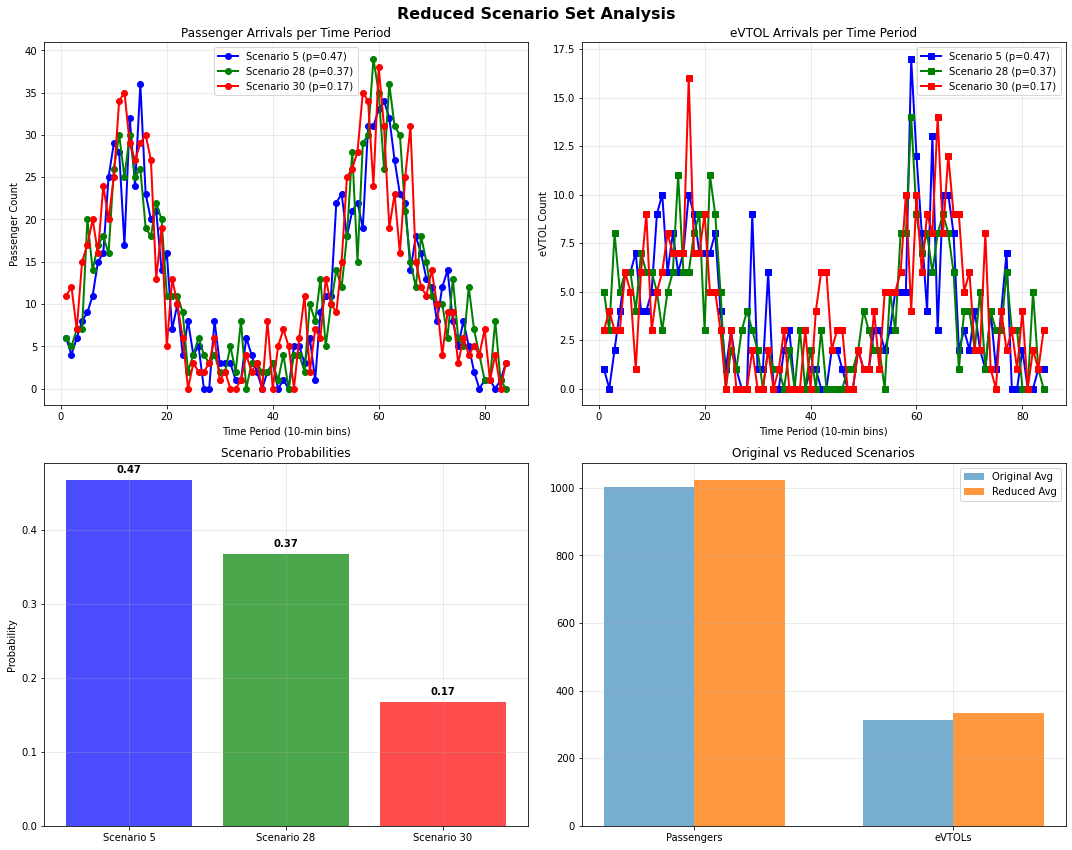

✅ Reduced to 3 representative scenarios.

 SCENARIO REDUCTION SUMMARY
Initial Scenarios: 30
Reduced to:        3 scenarios

Final Scenario Probabilities:
  Scenario 5   → p = 0.467
  Scenario 28  → p = 0.367
  Scenario 30  → p = 0.167

Average Total Passengers (Reduced): 1022.00
Average Total eVTOLs (Reduced):    332.33
Average Empirical Correlation (Reduced): [N/A – not computed]
 Pipeline successfully completed for hub DFW Airport.



In [10]:
# ============================================================
#  Main Execution — Minimal eVTOL Simulation Pipeline + Reduction
# ============================================================
if __name__ == "__main__":
    """
    Full eVTOL simulation pipeline (clean version):
        1. Load base vertiport scenario (pre-generated `result`)
        2. Simulate eVTOLs and passenger activity
        3. Build destination PMFs per time bin
        4. Generate 30 NHPP-based stochastic demand scenarios
        5. Apply backward scenario reduction (with eVTOL filtering)
        6. Output detailed reduction summary
    """

    # ------------------------------------------------------------
    #  Scenario Selection
    # ------------------------------------------------------------
    scenario = result                             
    HUB_NAME = scenario.get("hub", HUB_NAME)      
    TARGET_SCENARIOS = 3                          

    print("\n" + "=" * 70)
    print(f" Starting eVTOL Simulation Pipeline — Hub: {HUB_NAME}")
    print("=" * 70)

    # ------------------------------------------------------------
    #  Step 1: Scenario Generation
    # ------------------------------------------------------------
    print("\n[1] Loading base vertiport scenario...")
    print("✅ Scenario load complete.")

    # ------------------------------------------------------------
    #  Step 2: eVTOL and Passenger Simulation
    # ------------------------------------------------------------
    print("\n[2] Simulating eVTOL and passenger operations...")
    results = simulate_evtol_and_passengers(
        scenario_data=scenario,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        plot=False
    )
    print("✅ Simulation complete.")

    # ------------------------------------------------------------
    #  Step 3: Build Destination PMFs
    # ------------------------------------------------------------
    print("\n[3] Building destination PMFs per time bin...")
    pmfs, dests = build_bin_destination_pmfs(
        passenger_arrivals=scenario["passenger_arrivals"],                
        passenger_dest_names=scenario["passenger_destinations"],           
        target_shares=scenario.get("trips_by_dest_target", None),          
        blend_weight=0.15
    )
    print(f"✅ PMFs built for {len(pmfs)} time bins.")

    # ------------------------------------------------------------
    #  Step 4: Generate NHPP-Based Demand Scenarios
    # ------------------------------------------------------------
    print("\n[4] Generating stochastic demand scenarios (NHPP-based)...")
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=scenario["passenger_arrivals"],
        evtol_arrivals=scenario["evtol_arrivals"],
        destination_data=scenario["destinations"],
        bin_pmfs=pmfs,
        n_scenarios=N_SCENARIOS,     
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )
    print(f"✅ Generated {len(scenarios)} stochastic demand scenarios.")

    # ------------------------------------------------------------
    #  Step 5: Scenario Reduction
    # ------------------------------------------------------------
    print("\n[5] Performing backward scenario reduction with eVTOL filtering...")
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios=scenarios,
        target_size=TARGET_SCENARIOS,
        plot=True
    )
    print(f"✅ Reduced to {len(reduced_scenarios)} representative scenarios.")

    # ------------------------------------------------------------
    #  Step 6: Summary Report
    # ------------------------------------------------------------
    print("\n" + "=" * 90)
    print(" SCENARIO REDUCTION SUMMARY")
    print("=" * 90)
    print(f"Initial Scenarios: {len(scenarios)}")
    print(f"Reduced to:        {len(reduced_scenarios)} scenarios\n")

    print("Final Scenario Probabilities:")
    for s in reduced_scenarios:
        print(f"  Scenario {s['id']+1:<3} → p = {s['probability']:.3f}")

    avg_pass = np.mean([s["total_passengers"] for s in reduced_scenarios])
    avg_evtol = np.mean([s["total_evtols"] for s in reduced_scenarios])

    print("\nAverage Total Passengers (Reduced): "
          f"{avg_pass:.2f}")
    print("Average Total eVTOLs (Reduced):    "
          f"{avg_evtol:.2f}")

    if all("empirical_corr" in s for s in reduced_scenarios):
        avg_corr = np.mean([s["empirical_corr"] for s in reduced_scenarios])
        print(f"Average Empirical Correlation (Reduced): {avg_corr:.3f}")
    else:
        print("Average Empirical Correlation (Reduced): [N/A – not computed]")

    print("=" * 90)
    print(f" Pipeline successfully completed for hub {HUB_NAME}.")
    print("=" * 90 + "\n")


## Conditional Sampling of State of Charge (SoC)

In [11]:
# ============================================================
#  Conditional SoC Sampling per eVTOL (6 AM–8 PM)
# ============================================================

def conditional_soc_sampling_per_evtol(
        reduced_scenarios,
        assignment_case=None,
        s_base=50,
        k=12,
        sigma_base=3,
        sigma_scale=5,
        plot=False):
    """
    Conditional SoC sampling for each eVTOL.

    """

    case_label = {
        1: "Case 1 – Dallas CBD (Morning Peak)",
        2: "Case 2 – DFW Airport (Evening Peak)"
    }.get(assignment_case, "Unknown Case")

    # ------------------------------------------------------------
    # 1. Iterate through Reduced Scenarios
    # ------------------------------------------------------------
    for scenario in reduced_scenarios:
        a_t_omega = np.array(scenario['a_t'], dtype=float)
        e_t_omega = np.array(scenario['e_t'], dtype=float)

        # ------------------------------------------------------------
        # 2. Compute Load Ratios per Period (ρ_t_ω)
        # ------------------------------------------------------------
        rho_t_omega = np.divide(
            a_t_omega,
            np.maximum(e_t_omega, 1e-3),  # avoid division by zero
        )

        # smooth small gaps where eVTOL=0 using rolling interpolation
        for t in range(1, len(rho_t_omega)):
            if e_t_omega[t] == 0:
                rho_t_omega[t] = rho_t_omega[t-1]

        evtol_socs = {}
        evtol_arrival_periods = {}
        evtol_count = 0

        # ------------------------------------------------------------
        # 3. Adjust parameters by case
        # ------------------------------------------------------------
        if assignment_case == 1:   # Morning hub (Dallas CBD)
            s_base_adj = s_base + 2        # slightly higher base (early ops)
            k_adj = k                      # default slope
        elif assignment_case == 2: # Evening hub (DFW Airport)
            s_base_adj = s_base - 3        # slightly lower baseline (evening fatigue)
            k_adj = k * 1.1                # slightly steeper decline
        else:
            s_base_adj, k_adj = s_base, k

        # ------------------------------------------------------------
        # 4. Sample SoC for Each eVTOL
        # ------------------------------------------------------------
        for t in range(len(e_t_omega)):
            n_evtols = int(e_t_omega[t])
            if n_evtols <= 0:
                continue

            load_ratio = rho_t_omega[t]
            mu_s = s_base_adj - k_adj * load_ratio
            sigma_s = sigma_base + sigma_scale * load_ratio

            mu_s = np.clip(mu_s, 25, 55)
            sigma_s = np.clip(sigma_s, 2, 8)

            # Sample SoC values for all eVTOLs arriving at this period
            for _ in range(n_evtols):
                evtol_id = evtol_count
                evtol_arrival_periods[evtol_id] = t + 1
                # Re-sample until valid SoC is drawn
                soc_sample = None
                while soc_sample is None or not (20 <= soc_sample <= 60):
                    soc_sample = np.random.normal(mu_s, sigma_s)
                evtol_socs[evtol_id] = soc_sample
                evtol_count += 1

        # ------------------------------------------------------------
        # 5. Store Updated Scenario Data
        # ------------------------------------------------------------
        scenario['rho_t_omega'] = rho_t_omega
        scenario['evtol_socs'] = evtol_socs
        scenario['evtol_arrival_periods'] = evtol_arrival_periods
        scenario['total_evtols_count'] = evtol_count
        scenario['avg_load_ratio'] = np.mean(rho_t_omega)
        scenario['assignment_case'] = assignment_case

    # ------------------------------------------------------------
    # 6. Visualization (Optional)
    # ------------------------------------------------------------
    if plot:
        plt.figure(figsize=(12, 6))
        for s in reduced_scenarios:
            socs = list(s['evtol_socs'].values())
            plt.hist(socs, bins=8, alpha=0.6, edgecolor="black",
                     label=f"Scenario {s['id'] + 1}")
        plt.title(f"eVTOL State of Charge Distribution ({case_label}, 6 AM–6 PM)")
        plt.xlabel("State of Charge (%)")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    # ------------------------------------------------------------
    # 7. Return Updated Scenario Set
    # ------------------------------------------------------------
    return reduced_scenarios


In [12]:
# ============================================================
#  Main Execution — Full eVTOL Simulation Pipeline
# ============================================================
if __name__ == "__main__":
    """
    Full eVTOL simulation pipeline (enhanced version):
        1. Load base vertiport scenario (pre-generated `result`)
        2. Simulate eVTOLs and passenger activity
        3. Build destination PMFs per time bin
        4. Generate NHPP-based stochastic demand scenarios
        5. Perform backward scenario reduction with eVTOL filter
        6. Perform conditional SoC sampling
        7. Print detailed summary reports
    """

    # ------------------------------------------------------------
    #  Scenario Selection
    # ------------------------------------------------------------
    scenario = result
    HUB_NAME = scenario.get("hub", HUB_NAME)
    TARGET_SCENARIOS = 3

    print("\n==========================")
    print(f"Running eVTOL Pipeline — Hub: {HUB_NAME}")
    print("==========================")

    # ------------------------------------------------------------
    #  Step 1: Base Scenario (already loaded)
    # ------------------------------------------------------------

    # ------------------------------------------------------------
    #  Step 2: eVTOL and Passenger Simulation
    # ------------------------------------------------------------
    results = simulate_evtol_and_passengers(
        scenario_data=scenario,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        plot=False
    )

    # ------------------------------------------------------------
    #  Step 3: Build Destination PMFs
    # ------------------------------------------------------------
    pmfs, dests = build_bin_destination_pmfs(
        passenger_arrivals=scenario["passenger_arrivals"],
        passenger_dest_names=scenario["passenger_destinations"],
        target_shares=scenario.get("trips_by_dest_target", None),
        blend_weight=0.15
    )

    # ------------------------------------------------------------
    #  Step 4: Generate NHPP-Based Demand Scenarios
    # ------------------------------------------------------------
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=scenario["passenger_arrivals"],
        evtol_arrivals=scenario["evtol_arrivals"],
        destination_data=scenario["destinations"],
        bin_pmfs=pmfs,
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )

    # ------------------------------------------------------------
    #  Step 5: Scenario Reduction
    # ------------------------------------------------------------
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios=scenarios,
        target_size=TARGET_SCENARIOS,
        plot=False
    )

    # ------------------------------------------------------------
    #  Step 6: Conditional SoC Sampling
    # ------------------------------------------------------------
    scenarios_with_soc = conditional_soc_sampling_per_evtol(
        reduced_scenarios=reduced_scenarios,
        s_base=50,
        k=12,
        sigma_base=3,
        sigma_scale=5,
        assignment_case=None,  
        plot=False
    )

    # ------------------------------------------------------------
    #  Step 7: Conditional SoC Summary Report
    # ------------------------------------------------------------
    print("\n" + "=" * 90)
    print(" CONDITIONAL STATE-OF-CHARGE (SoC) SAMPLING SUMMARY")
    print("=" * 90)
    print(f"Reduced Scenarios Evaluated: {len(scenarios_with_soc)}\n")

    for s in scenarios_with_soc:
        soc_values = list(s["evtol_socs"].values())
        if len(soc_values) == 0:
            print(f"Scenario {s['id'] + 1:>2}: (No eVTOLs)")
            continue

        print(f"Scenario {s['id'] + 1:>2}:")
        print(f"  • Total eVTOLs:   {s['total_evtols_count']}")
        print(f"  • Avg Load Ratio: {s['avg_load_ratio']:.2f}")
        print(f"  • SoC Range:      {min(soc_values):.1f}% – {max(soc_values):.1f}%")
        print(f"  • Mean SoC:       {np.mean(soc_values):.1f}%")
        print(f"  • Std Dev (SoC):  {np.std(soc_values):.2f}\n")

    print("=" * 90)
    print(f"✅ Completed full pipeline for hub {HUB_NAME}.")



Running eVTOL Pipeline — Hub: DFW Airport

 CONDITIONAL STATE-OF-CHARGE (SoC) SAMPLING SUMMARY
Reduced Scenarios Evaluated: 3

Scenario  5:
  • Total eVTOLs:   320
  • Avg Load Ratio: 3.48
  • SoC Range:      20.2% – 54.8%
  • Mean SoC:       30.8%
  • Std Dev (SoC):  7.15

Scenario 28:
  • Total eVTOLs:   331
  • Avg Load Ratio: 3.24
  • SoC Range:      20.0% – 49.1%
  • Mean SoC:       30.6%
  • Std Dev (SoC):  6.95

Scenario 30:
  • Total eVTOLs:   346
  • Avg Load Ratio: 3.34
  • SoC Range:      20.3% – 57.2%
  • Mean SoC:       30.3%
  • Std Dev (SoC):  7.44

✅ Completed full pipeline for hub DFW Airport.


## Input Data Preparation for Stochastic Optimization Model

In [13]:
# ============================================================
#  Build Stochastic Optimization Model Input 
# ============================================================

import random
import numpy as np
from collections import defaultdict

def build_stochastic_model_input(
    reduced_scenarios,
    bin_pmfs,                               # <-- NEW: per-bin destination PMFs (list[dict{name: p}])
    m_facilities=M_FACILITIES,
    l_periods=L_PERIODS,                    # should equal (HORIZON_END - HORIZON_START)//BIN_SIZE
    SoC_min=SOC_MIN,
    c=BATTERY_CAPACITY,
    qr=CHARGING_RATE,
    LoS=LOS,
    eVTOL_capacity=EVTOL_CAPACITY,
    destination_fares=None,                 # {dest_id:int -> fare:float}
    destination_mapping=None,               # {"id_to_name":{id->name}, "name_to_id":{name->id}}
    verbose=True
):
    """
    Build model-ready stochastic input using reduced scenarios (with SoC) and
    time-binned destination PMFs..
    """

    # --------------------------- 0) Validation ---------------------------
    if destination_fares is None:
        raise ValueError(" Missing required parameter: destination_fares")
    if not destination_mapping or "id_to_name" not in destination_mapping or "name_to_id" not in destination_mapping:
        raise ValueError(" destination_mapping must contain {'id_to_name', 'name_to_id'}")
    if not isinstance(bin_pmfs, (list, tuple)) or len(bin_pmfs) != l_periods:
        raise ValueError(f" bin_pmfs must be a list of length l_periods={l_periods}")

    id_to_name = destination_mapping["id_to_name"]
    name_to_id = destination_mapping["name_to_id"]

    # --------------------- 1) Master structure header --------------------
    stochastic_input = {
        "scenarios": {},
        "global_parameters": {
            "m_facilities": m_facilities,
            "l_periods": l_periods,
            "SoC_min": SoC_min,
            "c": c,
            "qr": qr,
            "LoS": LoS,
            "eVTOL_capacity": eVTOL_capacity,
            "destination_fares": destination_fares,
            "destination_mapping": destination_mapping,
            "horizon": {
                "start_min": HORIZON_START,
                "end_min": HORIZON_END,
                "bin_size_min": BIN_SIZE
            }
        }
    }

    # --------------------- 2) Scenario-specific packing ------------------
    for scenario in reduced_scenarios:
        sid = int(scenario["id"])
        prob = float(scenario["probability"])

        # Safety: number of time bins must match
        a_t = np.asarray(scenario["a_t"], dtype=int)
        e_t = np.asarray(scenario["e_t"], dtype=int)
        if len(a_t) != l_periods or len(e_t) != l_periods:
            raise ValueError(f" Scenario {sid}: time series length mismatch with l_periods={l_periods}")

        # eVTOL counts / passengers (weights)
        n_evtols = int(scenario.get("total_evtols_count", e_t.sum()))
        w_passengers = int(a_t.sum())

        scenario_data = {
            "probability": prob,
            "n_evtols": n_evtols,
            "w_passengers": w_passengers,
            "evtols": {},                # j -> {arrival_time, arrival_bin, soc, charging_periods, finish_charging_period, charging_cost}
            "agg_pass_demand": {}        # (t_bin, dest_id) -> count
        }

        # -------- 2.1 eVTOL Arrivals & Charging using SoC samples --------
        # Prefer exact arrival bins from conditional sampling, else reconstruct from e_t
        evtol_arrival_bins = []
        if "evtol_arrival_periods" in scenario and scenario["evtol_arrival_periods"]:
            # Provided as 1-based bins
            ordered = sorted(scenario["evtol_arrival_periods"].items(), key=lambda kv: kv[0])  # by evtol_id
            evtol_arrival_bins = [int(b) for _, b in ordered]
        else:
            # Expand e_t into a list of 1-based arrival bins
            for t_bin, cnt in enumerate(e_t, start=1):
                evtol_arrival_bins.extend([t_bin] * int(cnt))

        # SoC values (already case-aware from previous step); fallback if missing
        soc_dict = scenario.get("evtol_socs", {})
        soc_values = [float(soc_dict.get(j, random.uniform(20, 60))) for j in range(len(evtol_arrival_bins))]

        # Convert bins to arrival times (uniform within the bin window)
        evtol_arrival_times = []
        for b in evtol_arrival_bins:
            start_min = HORIZON_START + (b - 1) * BIN_SIZE
            evtol_arrival_times.append(start_min + random.uniform(0, BIN_SIZE))

        # Compute charging details & TOU cost
        for j, (arrival_bin, arrival_time, soc) in enumerate(zip(evtol_arrival_bins, evtol_arrival_times, soc_values)):
            if soc < SoC_min:
                charge_needed_kWh = c * ((SoC_min - soc) / 100.0)
                hours_to_charge = charge_needed_kWh / qr
                periods_to_charge = hours_to_charge * (60.0 / BIN_SIZE)
                p_j = int(np.ceil(periods_to_charge))
                # Sum TOU price across periods
                total_cost = 0.0
                current_minute = arrival_time
                for _ in range(p_j):
                    current_hour = (current_minute % 1440) / 60.0
                    energy_this_period = qr / (60.0 / BIN_SIZE)  # kWh charged in one BIN
                    total_cost += energy_this_period * energy_price_per_kWh(current_hour)
                    current_minute += BIN_SIZE
                finish_period = min(arrival_bin + p_j, l_periods)
            else:
                p_j, finish_period, total_cost = 0, arrival_bin, 0.0

            scenario_data["evtols"][j] = {
                "arrival_time": arrival_time,
                "arrival_bin": arrival_bin,
                "soc": soc,
                "charging_periods": p_j,
                "finish_charging_period": finish_period,
                "charging_cost": total_cost
            }

        # -------- 2.2 Aggregate Passenger Demand via PMFs (time × dest) --------
        agg_pass_demand = defaultdict(int)
        # Precompute PMFs over destination **IDs** per bin
        # bin_pmfs[t] is {dest_name: p}; map to ids and ensure normalization
        pmf_ids = []
        for t in range(l_periods):
            pmf_t = bin_pmfs[t]
            # keep only destinations we know about (present in mapping)
            names, probs = zip(*[(nm, pmf_t[nm]) for nm in pmf_t if nm in name_to_id]) if pmf_t else ([], [])
            if names:
                ids = [name_to_id[nm] for nm in names]
                probs = np.array(probs, dtype=float)
                s = probs.sum()
                if s <= 0:
                    # fallback to uniform over known ids if something degenerate happens
                    probs = np.ones(len(ids), dtype=float) / len(ids)
                else:
                    probs = probs / s
                pmf_ids.append((ids, probs))
            else:
                # fallback: uniform over all destinations we have fares for
                ids = list(destination_fares.keys())
                probs = np.ones(len(ids), dtype=float) / max(1, len(ids))
                pmf_ids.append((ids, probs))

        # Sample destinations for each passenger arrival using the per-bin PMFs
        for t_bin, count in enumerate(a_t, start=1):
            if count <= 0:
                continue
            ids, probs = pmf_ids[t_bin - 1]
            draws = np.random.choice(ids, size=int(count), p=probs)
            for d in draws:
                agg_pass_demand[(t_bin, int(d))] += 1

        # Ensure every (t, d) pair exists (even if zero)
        for t_bin in range(1, l_periods + 1):
            for d in destination_fares.keys():
                agg_pass_demand.setdefault((t_bin, int(d)), 0)

        scenario_data["agg_pass_demand"] = dict(agg_pass_demand)
        stochastic_input["scenarios"][sid] = scenario_data

    # ------------------------- 3) Global ranges --------------------------
    all_evtols = [s["n_evtols"] for s in stochastic_input["scenarios"].values()]
    all_passengers = [s["w_passengers"] for s in stochastic_input["scenarios"].values()]
    stochastic_input["global_parameters"]["n_evtols_range"] = (int(min(all_evtols)), int(max(all_evtols)))
    stochastic_input["global_parameters"]["w_passengers_range"] = (int(min(all_passengers)), int(max(all_passengers)))

    # ------------------------ 4) Verbose summary -------------------------
    if verbose:
        print("=" * 90)
        print(" STOCHASTIC MODEL INPUT SUMMARY")
        print("=" * 90)
        print(f"Scenarios packed: {len(stochastic_input['scenarios'])}")
        print(f"Horizon: {HORIZON_START}–{HORIZON_END} min "
              f"({l_periods} periods × {BIN_SIZE}-min bins)\n")

        for sid, data in stochastic_input["scenarios"].items():
            print(f"Scenario {sid:2d} (p={data['probability']:.3f}):")
            print(f"  - eVTOLs:     {data['n_evtols']}")
            print(f"  - Passengers: {data['w_passengers']}")
            if data["evtols"]:
                print("  - eVTOL Details (first 8):")
                for eid, e in list(data["evtols"].items())[:8]:
                    print(f"      eVTOL {eid:3d}: Bin={e['arrival_bin']:3d}, "
                          f"Charge={e['charging_periods']:2d}p, "
                          f"SoC={e['soc']:5.1f}%, "
                          f"Cost=${e['charging_cost']:6.2f}")
            if data["agg_pass_demand"]:
                print("  - Demand (first 10 time–destination pairs):")
                shown = 0
                for (t, d), cnt in data["agg_pass_demand"].items():
                    if shown >= 10:
                        break
                    print(f"      Time {t:2d} → Dest {d:2d} ({id_to_name.get(d, 'Unknown'):<28}) : {cnt:3d}")
                    shown += 1
            print("-" * 80)

        print(f"\nRange of eVTOLs:     {min(all_evtols)}–{max(all_evtols)}")
        print(f"Range of Passengers: {min(all_passengers)}–{max(all_passengers)}")
        print("=" * 90)

    return stochastic_input


In [14]:
# ============================================================
#  Main Execution — Full eVTOL Simulation + Stochastic Input Pipeline
# ============================================================

if __name__ == "__main__":
    """
    Full pipeline sequence:
        1. Load base vertiport scenario (`result`)
        2. Simulate eVTOL & passenger arrivals
        3. Build PMFs for destination probabilities
        4. Generate stochastic demand scenarios
        5. Perform backward scenario reduction
        6. Perform conditional SoC sampling
        7. Build stochastic model input (optimization-ready)
        8. Print summary reports
    """

    # ------------------------------------------------------------
    # SCENARIO LOAD 
    # ------------------------------------------------------------
    scenario = result
    HUB_NAME = scenario.get("hub", HUB_NAME)

    print("\n==============================")
    print(f" Running Hub: {HUB_NAME}")
    print("==============================")

    # ------------------------------------------------------------
    # STEP 2 — eVTOL & Passenger Simulation 
    # ------------------------------------------------------------
    results = simulate_evtol_and_passengers(
        scenario_data=scenario,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        plot=False
    )

    # ------------------------------------------------------------
    # STEP 3 — Build Destination PMFs 
    # ------------------------------------------------------------
    pmfs, dests = build_bin_destination_pmfs(
        passenger_arrivals=scenario["passenger_arrivals"],
        passenger_dest_names=scenario["passenger_destinations"],
        target_shares=scenario.get("trips_by_dest_target", None),
        blend_weight=0.15
    )

    # ------------------------------------------------------------
    # STEP 4 — Generate NHPP-Based Demand Scenarios 
    # ------------------------------------------------------------
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=scenario["passenger_arrivals"],
        evtol_arrivals=scenario["evtol_arrivals"],
        destination_data=scenario["destinations"],
        bin_pmfs=pmfs,
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )

    # ------------------------------------------------------------
    # STEP 5 — Scenario Reduction 
    # ------------------------------------------------------------
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios,
        target_size=TARGET_SCENARIOS,
        plot=False
    )

    # ------------------------------------------------------------
    # STEP 6 — Conditional SoC Sampling 
    # ------------------------------------------------------------
    scenarios_with_soc = conditional_soc_sampling_per_evtol(
        reduced_scenarios=reduced_scenarios,
        s_base=50,
        k=12,
        sigma_base=3,
        sigma_scale=5,
        assignment_case=None,   # ✅ no FIXED_CASE
        plot=False
    )

    # ------------------------------------------------------------
    # STEP 7 — Build Stochastic Optimization Input 
    # ------------------------------------------------------------
    # Build destination id mapping from available destinations
    dest_names = list(scenario["destinations"].keys())
    name_to_id = {nm: i + 1 for i, nm in enumerate(dest_names)}
    id_to_name = {i + 1: nm for i, nm in enumerate(dest_names)}

    destination_mapping = {
        "id_to_name": id_to_name,
        "name_to_id": name_to_id
    }

    destination_fares = {
        name_to_id[name]: data["fare"]
        for name, data in scenario["destinations"].items()
    }

    stochastic_input = build_stochastic_model_input(
        reduced_scenarios=scenarios_with_soc,
        bin_pmfs=pmfs,
        destination_fares=destination_fares,
        destination_mapping=destination_mapping,
        verbose=True
    )

    # ------------------------------------------------------------
    # STEP 8 — Summary Reports 
    # ------------------------------------------------------------
    gp = stochastic_input["global_parameters"]
    print("\n" + "=" * 90)
    print("🧮 STOCHASTIC MODEL INPUT SUMMARY (GLOBAL)")
    print("=" * 90)
    print(f"Facilities:       {gp['m_facilities']}")
    print(f"Periods:          {gp['l_periods']} × {gp['horizon']['bin_size_min']} min")
    print(f"SoC_min:          {gp['SoC_min']}%")
    print(f"Charging Rate:    {gp['qr']} kW")
    print(f"LoS Limit:        {gp['LoS']} periods")
    print(f"Destinations:     {len(gp['destination_fares'])}")
    print(f"Scenario Range eVTOLs: {gp['n_evtols_range']}")
    print(f"Scenario Range Pax:    {gp['w_passengers_range']}")
    print("=" * 90)

    print(f"✅ Completed full pipeline for hub {HUB_NAME}.\n")



 Running Hub: DFW Airport
 STOCHASTIC MODEL INPUT SUMMARY
Scenarios packed: 3
Horizon: 360–1200 min (84 periods × 10-min bins)

Scenario  4 (p=0.467):
  - eVTOLs:     320
  - Passengers: 985
  - eVTOL Details (first 8):
      eVTOL   0: Bin=  1, Charge= 4p, SoC= 20.5%, Cost=$ 12.97
      eVTOL   1: Bin=  3, Charge= 4p, SoC= 24.0%, Cost=$ 12.97
      eVTOL   2: Bin=  3, Charge= 3p, SoC= 32.8%, Cost=$  9.73
      eVTOL   3: Bin=  4, Charge= 4p, SoC= 25.7%, Cost=$ 12.97
      eVTOL   4: Bin=  4, Charge= 4p, SoC= 27.0%, Cost=$ 12.97
      eVTOL   5: Bin=  4, Charge= 3p, SoC= 34.5%, Cost=$  9.73
      eVTOL   6: Bin=  4, Charge= 3p, SoC= 30.4%, Cost=$  9.73
      eVTOL   7: Bin=  5, Charge= 3p, SoC= 32.8%, Cost=$  9.73
  - Demand (first 10 time–destination pairs):
      Time  1 → Dest  2 (Dallas Love Field Airport   ) :   4
      Time  1 → Dest  6 (Denton Municipal Airport    ) :   1
      Time  1 → Dest  9 (McKinney National Airport   ) :   1
      Time  2 → Dest  3 (Fort Worth City Cente

## Stochastic Optimization Model Fourmulation

In [15]:
# ============================================================
#  STOCHASTIC eVTOL SCHEDULING MODEL (GUROBI)
# ============================================================

import gurobipy as grb


def build_and_solve_stochastic_model_aggregated(
    stochastic_input,
    M=1000,
    verbose=True,
):
    """
    Build and solve a **stochastic aggregated eVTOL scheduling model** using Gurobi.

    The model optimizes eVTOL charging assignments, passenger service allocation,
    and revenue–cost tradeoffs across multiple stochastic demand scenarios.

    Steps:
        1. Extract global data and indices
        2. Define decision variables (charging, assignment, service)
        3. Add logical and operational constraints
        4. Define revenue, charging, and penalty components
        5. Maximize expected profit
        6. Solve and report results

    Parameters
    ----------
    stochastic_input : dict
        Structured data from `build_stochastic_model_input()`.
    M : float, default=1000
        Big-M constant for logical linking constraints.
    verbose : bool, default=True
        Toggle solver output.
    Returns
    -------
    model : gurobipy.Model
        The optimized Gurobi model.
    results : dict
        Summary of optimization outcomes.
    """

    # =====================================================
    #  Extract Global Parameters and Sets
    # =====================================================
    global_params = stochastic_input["global_parameters"]
    m_facilities = global_params["m_facilities"]
    l_periods = global_params["l_periods"]
    eVTOL_capacity = global_params["eVTOL_capacity"]
    LoS = global_params["LoS"]
    destination_fares = global_params["destination_fares"]

    I = list(range(m_facilities))        # Facilities
    Time = list(range(1, l_periods + 1)) # Time bins
    S = list(stochastic_input["scenarios"].keys())  # Scenarios
    D = list(destination_fares.keys())   # Destinations

    # =====================================================
    #  Initialize Model
    # =====================================================
    model = grb.Model("Stochastic_eVTOL_Scheduling")
    if not verbose:
        model.Params.OutputFlag = 0
    model.Params.MIPGap = 0.05
    model.Params.TimeLimit = 300
    model.Params.DualReductions = 0

    # =====================================================
    #  Decision Variables
    # =====================================================
    x, C, F, z, pass_assigned, unserved_pass, Y, Tvar, use_evtol = {}, {}, {}, {}, {}, {}, {}, {}, {}

    for s in S:
        scenario = stochastic_input["scenarios"][s]
        n_evtols = scenario["n_evtols"]
        J = list(range(n_evtols))

        # eVTOL activation
        for j in J:
            use_evtol[j, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"use_{j}_{s}")

        # Charging assignment: x[i,j,t,s]
        for i in I:
            for j in J:
                for t in Time:
                    x[i, j, t, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"x_{i}_{j}_{t}_{s}")

        # Completion & takeoff times
        for j in J:
            C[j, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"C_{j}_{s}")
            F[j, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"F_{j}_{s}")

            for d in D:
                z[j, d, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"z_{j}_{d}_{s}")

            for t in Time:
                for d in D:
                    pass_assigned[j, t, d, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"pass_{j}_{t}_{d}_{s}")
                    Y[j, t, d, s] = model.addVar(vtype=grb.GRB.BINARY, name=f"Y_{j}_{t}_{d}_{s}")
                    Tvar[j, t, d, s] = model.addVar(lb=0, vtype=grb.GRB.CONTINUOUS, name=f"T_{j}_{t}_{d}_{s}")

        # Unserved passengers
        for t in Time:
            for d in D:
                unserved_pass[t, d, s] = model.addVar(vtype=grb.GRB.INTEGER, name=f"unserved_{t}_{d}_{s}")

    model.update()

    # =====================================================
    #  Constraints (Scenario-specific)
    # =====================================================
    for s in S:
        scenario = stochastic_input["scenarios"][s]
        n_evtols = scenario["n_evtols"]
        J = list(range(n_evtols))

        r = {j: scenario["evtols"][j]["arrival_bin"] for j in J}
        p = {j: scenario["evtols"][j]["charging_periods"] for j in J}
        charging_cost = {j: scenario["evtols"][j]["charging_cost"] for j in J}
        agg_pass_demand = scenario["agg_pass_demand"]

        # (1) Feasible charging assignment or deactivation
        for j in J:
            start, end = r[j], l_periods - p[j] + 1
            if start <= end:
                model.addConstr(grb.quicksum(x[i, j, t, s] for i in I for t in range(start, end + 1)) == use_evtol[j, s])
            else:
                model.addConstr(use_evtol[j, s] == 0)
                for i in I:
                    for t in Time:
                        model.addConstr(x[i, j, t, s] == 0)

        # (2) Facility capacity: one eVTOL per facility per period
        for i in I:
            for t in Time:
                model.addConstr(
                    grb.quicksum(x[i, j, u, s] for j in J for u in range(max(1, t - p[j] + 1), t + 1) if u >= r[j]) <= 1
                )

        # (3) Completion and takeoff
        for j in J:
            model.addConstr(C[j, s] == grb.quicksum((t + p[j] - 1) * x[i, j, t, s] for i in I for t in Time))
            model.addConstr(F[j, s] >= C[j, s])

        # (4) Destination and capacity linkage
        for j in J:
            model.addConstr(grb.quicksum(z[j, d, s] for d in D) <= use_evtol[j, s])
            model.addConstr(grb.quicksum(pass_assigned[j, t, d, s] for t in Time for d in D)
                            <= eVTOL_capacity * use_evtol[j, s])

        # (5) Link passengers → Y and Y → destination
        for j in J:
            for t in Time:
                for d in D:
                    model.addConstr(pass_assigned[j, t, d, s] <= eVTOL_capacity * Y[j, t, d, s])
            for d in D:
                model.addConstr(grb.quicksum(Y[j, t, d, s] for t in Time) <= M * z[j, d, s])

        # (6) Demand balance
        for t in Time:
            for d in D:
                model.addConstr(
                    grb.quicksum(pass_assigned[j, t, d, s] for j in J) + unserved_pass[t, d, s] == agg_pass_demand[t, d]
                )

        # (7) Level of Service (tardiness bounds)
        for j in J:
            for t in Time:
                for d in D:
                    model.addConstr(Tvar[j, t, d, s] >= F[j, s] - t - M * (1 - Y[j, t, d, s]))
                    model.addConstr(Tvar[j, t, d, s] <= LoS + M * (1 - Y[j, t, d, s]))
                    model.addConstr(Tvar[j, t, d, s] >= 0)

    # =====================================================
    #  Objective Function (Expected Profit)
    # =====================================================
    total_revenue, total_costs, total_penalty = 0, 0, 0

    for s in S:
        scenario = stochastic_input["scenarios"][s]
        prob = scenario["probability"]
        n_evtols = scenario["n_evtols"]
        J = list(range(n_evtols))
        charging_cost = {j: scenario["evtols"][j]["charging_cost"] for j in J}

        revenue = grb.quicksum(
            pass_assigned[j, t, d, s] * destination_fares[d]
            for j in J for t in Time for d in D
        )
        charge_cost = grb.quicksum(
            charging_cost[j] * grb.quicksum(x[i, j, t, s] for i in I for t in Time)
            for j in J
        )
        penalty = grb.quicksum(destination_fares[d] * unserved_pass[t, d, s] for t in Time for d in D)

        total_revenue += prob * revenue
        total_costs += prob * charge_cost
        total_penalty += prob * penalty

    model.setObjective(total_revenue - total_costs - total_penalty, grb.GRB.MAXIMIZE)

    # =====================================================
    #  Solve Model
    # =====================================================
    print("\n Solving stochastic scheduling model...")
    model.optimize()

    # =====================================================
    #  Status Reporting
    # =====================================================
    if model.Status == grb.GRB.OPTIMAL:
        print("✅ Optimal solution found.")
        print(f"   Objective Value: ${model.ObjVal:,.2f}")
    elif model.Status == grb.GRB.INFEASIBLE:
        print("❌ Model infeasible. Writing IIS to 'inf.ilp' ...")
        model.computeIIS()
        model.write("inf.ilp")
    elif model.Status == grb.GRB.UNBOUNDED:
        print(" Model unbounded.")
    elif model.Status == grb.GRB.INF_OR_UNBD:
        print(" Model infeasible or unbounded.")
    else:
        print(f" Optimization ended with status code {model.Status}.")

    # =====================================================
    #  Scenario-Wise Detailed Reporting
    # =====================================================
    if model.Status == grb.GRB.OPTIMAL:
        print("\n DETAILED RESULTS PER SCENARIO\n")
        for s in S:
            scenario = stochastic_input["scenarios"][s]
            prob = scenario["probability"]
            J = list(scenario["evtols"].keys())
            charging_cost = {j: scenario["evtols"][j]["charging_cost"] for j in J}

            served = sum(pass_assigned[j, t, d, s].X for j in J for t in Time for d in D)
            unserved = sum(unserved_pass[t, d, s].X for t in Time for d in D)
            revenue = sum(pass_assigned[j, t, d, s].X * destination_fares[d] for j in J for t in Time for d in D)
            lost = sum(unserved_pass[t, d, s].X * destination_fares[d] for t in Time for d in D)
            charge = sum(charging_cost[j] * sum(x[i, j, t, s].X for i in I for t in Time) for j in J)
            net = revenue - lost - charge

            print(f" Scenario {s} (p={prob:.2f}) → Served={served}, Unserved={unserved}, Net=${net:,.2f}")

    # =====================================================
    #  Return Results
    # =====================================================
    return model, {
        "status": model.Status,
        "objective": model.ObjVal if model.SolCount > 0 else None
    }


# Main Code

In [19]:
# ============================================================
#  Main Execution — Full eVTOL Simulation + Stochastic Input Pipeline
# ============================================================

if __name__ == "__main__":
    """
    Full pipeline sequence:
        1. Load base vertiport scenario (`result`)
        2. Simulate eVTOL & passenger arrivals
        3. Build PMFs for destination probabilities
        4. Generate stochastic demand scenarios
        5. Perform backward scenario reduction
        6. Perform conditional SoC sampling
        7. Build stochastic model input (optimization-ready)
        8. Solve stochastic optimization model
        9. Summary output
    """

    # ------------------------------------------------------------
    # SCENARIO LOAD  
    # ------------------------------------------------------------
    scenario = result
    HUB_NAME = scenario.get("hub", HUB_NAME)

    print("\n==============================")
    print(f" Running Hub: {HUB_NAME}")
    print("==============================")

    # ------------------------------------------------------------
    # STEP 2 — eVTOL & Passenger Simulation
    # ------------------------------------------------------------
    print("\n[2] Simulating eVTOL & passenger operations...")
    sim_results = simulate_evtol_and_passengers(
        scenario_data=scenario,
        soc_min=SOC_MIN,
        battery_capacity=BATTERY_CAPACITY,
        charging_rate=CHARGING_RATE,
        plot=False
    )
    print("✅ Simulation complete.")

    # ------------------------------------------------------------
    # STEP 3 — Build Destination PMFs (per time bin)
    # ------------------------------------------------------------
    print("\n[3] Building destination PMFs per time bin...")
    pmfs, dests = build_bin_destination_pmfs(
        passenger_arrivals=scenario["passenger_arrivals"],
        passenger_dest_names=scenario["passenger_destinations"],         
        target_shares=scenario.get("trips_by_dest_target", None),        
        blend_weight=0.15
    )
    print(f"✅ PMFs built for {len(pmfs)} time bins.")

    # ------------------------------------------------------------
    # STEP 4 — Generate NHPP-Based Demand Scenarios
    # ------------------------------------------------------------
    print("\n[4] Generating NHPP-based stochastic demand scenarios...")
    scenarios = generate_joint_demand_scenarios(
        passenger_arrivals=scenario["passenger_arrivals"],
        evtol_arrivals=scenario["evtol_arrivals"],
        destination_data=scenario["destinations"],
        bin_pmfs=pmfs,
        n_scenarios=N_SCENARIOS,
        horizon_minutes=HORIZON_MINUTES,
        bin_size=BIN_SIZE,
        plot=False
    )
    print(f"✅ Generated {len(scenarios)} stochastic demand scenarios.")

    # ------------------------------------------------------------
    # STEP 5 — Scenario Reduction
    # ------------------------------------------------------------
    print("\n[5] Performing backward scenario reduction (eVTOL-filtered)...")
    reduced_scenarios = scenario_reduction_backward_with_evtol_filter(
        scenarios,
        target_size=TARGET_SCENARIOS,
        plot=False
    )
    print(f"✅ Reduced to {len(reduced_scenarios)} representative scenarios.")

    # ------------------------------------------------------------
    # STEP 6 — Conditional SoC Sampling
    # ------------------------------------------------------------
    print("\n[6] Sampling conditional SoC per reduced scenario...")
    scenarios_with_soc = conditional_soc_sampling_per_evtol(
        reduced_scenarios=reduced_scenarios,
        s_base=50,
        k=12,
        sigma_base=3,
        sigma_scale=5,
        assignment_case=None,   
        plot=False
    )
    print("✅ Conditional SoC sampling complete.")

    # ------------------------------------------------------------
    # STEP 7 — Build Stochastic Optimization Input
    # ------------------------------------------------------------
    print("\n[7] Building optimization-ready stochastic input...")

    # ✅ changed: build mapping locally (no scenario['destination_map'] / ['name_to_number'])
    dest_names = list(scenario["destinations"].keys())
    name_to_id = {nm: i + 1 for i, nm in enumerate(dest_names)}
    id_to_name = {i + 1: nm for i, nm in enumerate(dest_names)}

    destination_mapping = {
        "id_to_name": id_to_name,
        "name_to_id": name_to_id
    }

    destination_fares = {
        name_to_id[name]: data["fare"]
        for name, data in scenario["destinations"].items()
    }

    stochastic_input = build_stochastic_model_input(
        reduced_scenarios=scenarios_with_soc,
        bin_pmfs=pmfs,
        destination_fares=destination_fares,
        destination_mapping=destination_mapping,
        verbose=False
    )
    print("✅ Stochastic model input built.")

    # ------------------------------------------------------------
    # STEP 8 — Build and Solve the Stochastic Optimization Model
    # ------------------------------------------------------------
    print("\n[8] Running Stochastic Optimization Model (Gurobi)...")
    model, opt_results = build_and_solve_stochastic_model_aggregated(
        stochastic_input=stochastic_input,
        M=1000,
        verbose=True,
    )

    # ------------------------------------------------------------
    # STEP 9 — Summary Output
    # ------------------------------------------------------------
    print("\n" + "=" * 100)
    print(" FULL STOCHASTIC PIPELINE COMPLETED SUCCESSFULLY ✅")
    if opt_results.get("objective") is not None:
        print(f"Final Objective Value: ${opt_results['objective']:,.2f}")
    print("=" * 100)



 Running Hub: DFW Airport

[2] Simulating eVTOL & passenger operations...
✅ Simulation complete.

[3] Building destination PMFs per time bin...
✅ PMFs built for 84 time bins.

[4] Generating NHPP-based stochastic demand scenarios...
✅ Generated 30 stochastic demand scenarios.

[5] Performing backward scenario reduction (eVTOL-filtered)...
✅ Reduced to 3 representative scenarios.

[6] Sampling conditional SoC per reduced scenario...
✅ Conditional SoC sampling complete.

[7] Building optimization-ready stochastic input...
✅ Stochastic model input built.

[8] Running Stochastic Optimization Model (Gurobi)...
Set parameter MIPGap to value 0.05
Set parameter TimeLimit to value 300
Set parameter DualReductions to value 0

 Solving stochastic scheduling model...
Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-6700HQ CPU @ 2.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up t

GurobiError: Model too large for size-limited license; visit https://gurobi.com/unrestricted for more information